# 08 · Galaxy luminosity functions

*ugriz* luminosity functions from L-GALAXIES' own magnitudes and from the PCA reconstruction, intrinsic and dust-attenuated, with an SDSS reference.

**Execution model — run end-to-end.** About a minute.

> The effective volume is `box³ × n_files_used / n_total_files`, and the LF **amplitude** scales with it. Both the box size and the file count come from `galspectra.trees`, so they cannot disagree with the selected tree — which is how the earlier Millennium-II variant came to carry a Millennium-I box-size comment beside a Millennium-II value. The file count is derived from the file range rather than stored beside it, so the two cannot drift either. Note the equal-volume assumption documented on `Tree.effective_volume_mpc_h3`.

Computes and compares the rest-frame galaxy luminosity function (LF) at z = 0 in all five
SDSS *ugriz* bands using two magnitude sources:

| Source | Intrinsic | Dust-attenuated |
|--------|-----------|----------------|
| **L-GALAXIES** | `Mag` (from SSP spectral tables) | `MagDust` |
| **PCA reconstruction** | `synth_mag_*` | `synth_magdust_*` |

**Figures produced:**
1. Main LF comparison — 2 rows (intrinsic / dust-attenuated) × 5 columns (ugriz)
2. PCA / L-GALAXIES ratio — same grid, shows where the LFs deviate
3. r-band summary — all four LFs on one panel with SDSS Schechter reference

**Caveats:**
- The sample uses the tree files in `TREE.file_range`. Adjust
  `N_TOTAL_FILES` and `N_FILES_USED` if you run on more files.
- Poisson errors dominate at the bright end (few massive galaxies in 1/512 of the box).
- HI luminosity function is *not* included here (future task).

## Merger tree

Set `TREE` below. Every per-tree constant comes from `galspectra.trees`, so the
tree is chosen in exactly one place and the sample file cannot disagree with the
coefficient product.


In [2]:
# ── Merger tree ─────────────────────────────────────────────────────────────
# "MR"   Millennium-I   (default)
# "MRII" Millennium-II  — trees live on an external drive and there is no
#                         galaxy_table_MRII.npz, so this is often unavailable.
#
# Every per-tree constant comes from galspectra.trees, so the sample file and the
# coefficient product cannot disagree about which simulation this is. Selecting a
# tree whose data is absent fails immediately, naming the path: TREE.require()
# never falls back to the other tree, because that would mean every number below
# quietly described a different simulation from the one in the heading.
from galspectra.trees import get_tree

TREE = get_tree("MR")          # Millennium-I
print(f"Tree: {TREE.label}  ({TREE.pretty})")


Tree: MR  (Millennium-I)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR    = Path('.').resolve()
GALSPECTRA_ROOT = NOTEBOOK_DIR.parent
LGAL_ROOT       = GALSPECTRA_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'

SAMPLE_FILE   = TREE.require(TREE.sample_path(LGAL_ROOT),
                             'the L-GALAXIES galaxy sample')
POSTPROC_FILE = TREE.require(TREE.coeffs_path(GALSPECTRA_ROOT / 'data'),
                             'the PCA coefficient product')

# ── Volume parameters ──────────────────────────────────────────────────────
# Adjust N_FILES_USED and N_TOTAL_FILES when running on more tree files.
BOX_SIZE_MPCh  = TREE.box_mpc_h        # comoving box side [Mpc/h]
N_TOTAL_FILES  = TREE.n_total_files    # tree files the simulation is split into
N_FILES_USED   = TREE.n_files_used     # derived from TREE.file_range
# Assumes the tree files partition the box into equal volumes — see the
# docstring of Tree.effective_volume_mpc_h3. The LF *amplitude* below scales
# directly with this number.
V_EFF          = TREE.effective_volume_mpc_h3   # (Mpc/h)^3

# ── Magnitude binning ──────────────────────────────────────────────────────
MAG_MIN  = -27.0
MAG_MAX  = -12.0
MAG_DBIN = 0.5              # bin width [mag]
MAG_BINS = np.arange(MAG_MIN, MAG_MAX + MAG_DBIN, MAG_DBIN)
N_MIN_BINS = 5              # bins with fewer galaxies shown as upper limits / greyed out

# ── Cosmology ──────────────────────────────────────────────────────────────
HUB_H = 0.673

BANDS     = ['u', 'g', 'r', 'i', 'z']
BAND_IDX  = {b: i for i, b in enumerate(BANDS)}
BAND_LEFF = {'u': 3551, 'g': 4686, 'r': 6165, 'i': 7481, 'z': 8931}

print(f'Effective volume : {V_EFF:.3e} (Mpc/h)^3')
print(f'                 = {V_EFF / HUB_H**3:.3e} Mpc^3')
print(f'Magnitude bins   : {MAG_MIN} to {MAG_MAX}, step {MAG_DBIN} ({len(MAG_BINS)-1} bins)')
print(f'Tree             : {TREE.label}  ({TREE.pretty}, box {BOX_SIZE_MPCh:g} Mpc/h)')

Effective volume : 2.164e+05 (Mpc/h)^3
                 = 7.098e+05 Mpc^3
Magnitude bins   : -27.0 to -12.0, step 0.5 (30 bins)
Tree             : MR  (Millennium-I, box 480.279 Mpc/h)


## 1. Load data

In [4]:
# ── L-GALAXIES sample ─────────────────────────────────────────────────────
G = np.load(SAMPLE_FILE, allow_pickle=True)
print(f'Sample: {len(G):,} galaxies')

lgal_mag      = G['Mag']      # (N, 5) intrinsic absolute AB mags;  sentinel = 90.0
lgal_magdust  = G['MagDust']  # (N, 5) dust-attenuated

# Valid-magnitude masks (band-independent: use r as reference for counting)
valid_int  = lgal_mag[:, BAND_IDX['r']]     < 90.0
valid_dust = lgal_magdust[:, BAND_IDX['r']] < 90.0
print(f'  Valid intrinsic (r < 90): {valid_int.sum():,}   '
      f'Valid dust-att. (r < 90): {valid_dust.sum():,}')

# ── PCA post-processing ────────────────────────────────────────────────────
pp = np.load(POSTPROC_FILE, allow_pickle=True)
pp_gidx = pp['galaxy_index']    # indices into G; check sequential
assert np.all(np.diff(pp_gidx) == 1) and pp_gidx[0] == 0, \
    'galaxy_index not sequential — re-check alignment'

pca_mag     = {b: pp[f'synth_mag_{b}'].astype(np.float64)     for b in BANDS}  # intrinsic
pca_magdust = {b: pp[f'synth_magdust_{b}'].astype(np.float64) for b in BANDS}  # dust-att.

# Sentinels: PCA mags should all be finite; flag non-finite as invalid
print(f'\nPCA post-processing: {len(pp_gidx):,} galaxies')
for b in BANDS:
    n_inf = np.sum(~np.isfinite(pca_mag[b]))
    if n_inf:
        print(f'  WARNING: {n_inf} non-finite PCA synth_mag_{b}')

Sample: 11,328 galaxies
  Valid intrinsic (r < 90): 10,191   Valid dust-att. (r < 90): 10,149

PCA post-processing: 11,328 galaxies


## 2. LF computation helpers

In [5]:
def compute_lf(mags, V_eff_h3, mag_bins):
    """
    Volume-limited luminosity function.  mags must already have sentinel/NaN
    values removed by the caller.

    Returns
    -------
    centres : (N_bins,) bin centres [mag]
    phi     : (N_bins,) number density [(Mpc/h)^-3 mag^-1]
    err     : (N_bins,) Poisson uncertainty [(Mpc/h)^-3 mag^-1]
    counts  : (N_bins,) raw counts per bin
    """
    counts, edges = np.histogram(mags, bins=mag_bins)
    dM      = np.diff(edges)                          # bin widths
    centres = 0.5 * (edges[:-1] + edges[1:])
    phi     = counts / (V_eff_h3 * dM)
    err     = np.sqrt(np.maximum(counts, 1)) / (V_eff_h3 * dM)
    return centres, phi, err, counts


def schechter_r(M_r, hub_h=HUB_H):
    """
    SDSS r-band Schechter LF from Blanton et al. 2003 (z~0.1, h=1).
    Converted to h=0.673 units: M* → M* + 5*log10(h), φ* → φ* * h^3.

    Returns φ in (Mpc/h)^-3 mag^-1.
    """
    M_star = -20.44 + 5.0 * np.log10(hub_h)    # ≈ -21.30 for h=0.673
    alpha  = -1.05
    phi_st = 1.49e-2 * hub_h**3                # (Mpc/h)^-3
    x = 10.0 ** (0.4 * (M_star - M_r))
    return (0.4 * np.log(10) * phi_st
            * x**(alpha + 1) * np.exp(-x))


print('compute_lf and schechter_r defined.')
M_test = np.array([-22.0, -20.0, -18.0])
print(f'  Schechter at M_r = {M_test}: '
      f'{schechter_r(M_test)}')

compute_lf and schechter_r defined.
  Schechter at M_r = [-22. -20. -18.]: [0.00060244 0.00328354 0.00464213]


## 3. Compute all luminosity functions

In [6]:
# Store results as dicts keyed by band
lf = {}   # lf['lgal_int']['r'] = (centres, phi, err, counts)

for key in ('lgal_int', 'lgal_dust', 'pca_int', 'pca_dust'):
    lf[key] = {}

for b in BANDS:
    bi = BAND_IDX[b]

    # L-GALAXIES intrinsic — valid where Mag < 90
    m_lg_i = lgal_mag[:, bi]
    lf['lgal_int'][b]  = compute_lf(m_lg_i[m_lg_i < 90.], V_EFF, MAG_BINS)

    # L-GALAXIES dust-attenuated
    m_lg_d = lgal_magdust[:, bi]
    lf['lgal_dust'][b] = compute_lf(m_lg_d[m_lg_d < 90.], V_EFF, MAG_BINS)

    # PCA intrinsic — valid where finite
    m_pca_i = pca_mag[b]
    lf['pca_int'][b]   = compute_lf(m_pca_i[np.isfinite(m_pca_i)], V_EFF, MAG_BINS)

    # PCA dust-attenuated
    m_pca_d = pca_magdust[b]
    lf['pca_dust'][b]  = compute_lf(m_pca_d[np.isfinite(m_pca_d)], V_EFF, MAG_BINS)

# Quick summary
print(f'{"Band":<5}  '
      f'{"N(lgal_int)":>12} {"N(lgal_dust)":>13} '
      f'{"N(pca_int)":>11} {"N(pca_dust)":>11}')
print('-' * 58)
for b in BANDS:
    ni_lg  = lf['lgal_int'][b][3].sum()
    nd_lg  = lf['lgal_dust'][b][3].sum()
    ni_pca = lf['pca_int'][b][3].sum()
    nd_pca = lf['pca_dust'][b][3].sum()
    print(f'{b:<5}  {ni_lg:>12,} {nd_lg:>13,} {ni_pca:>11,} {nd_pca:>11,}')

Band    N(lgal_int)  N(lgal_dust)  N(pca_int) N(pca_dust)
----------------------------------------------------------
u            10,191        10,149      11,328      11,328
g            10,191        10,149      11,328      11,328
r            10,191        10,149      11,328      11,328
i            10,191        10,149      11,328      11,328
z            10,191        10,149      11,328      11,328


## 4. Main LF figure — intrinsic (row 0) and dust-attenuated (row 1)

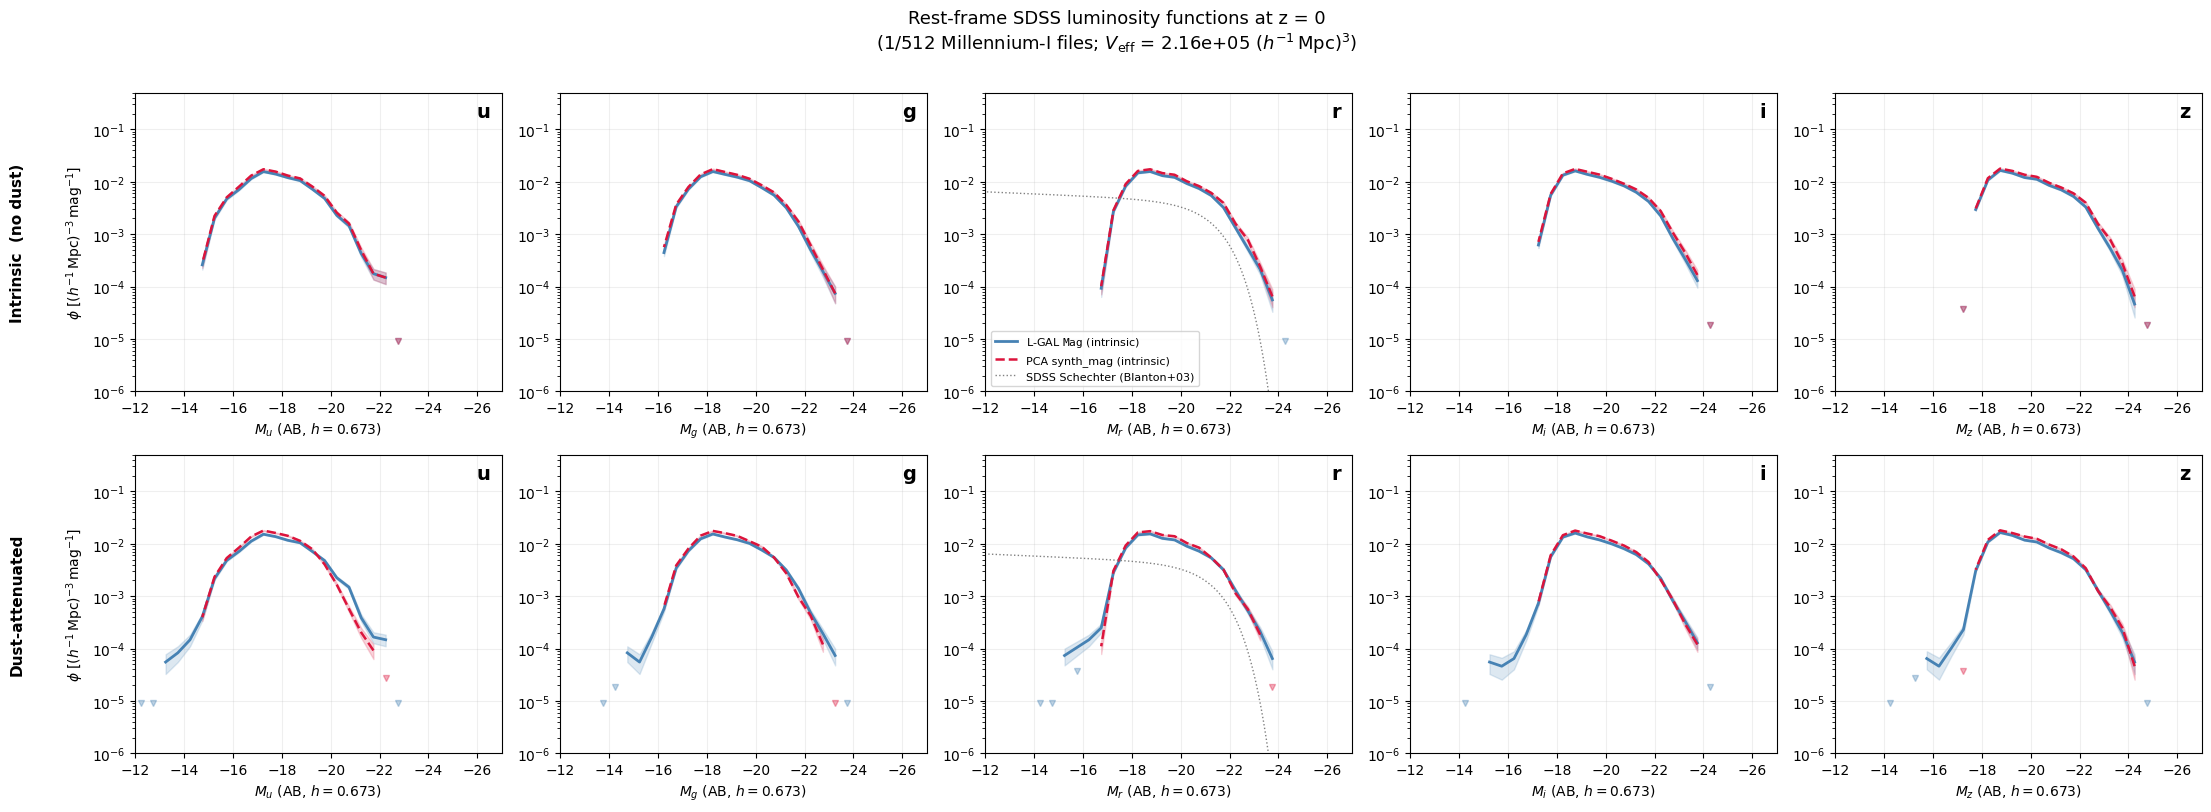

In [7]:
# ── Plot style helpers ─────────────────────────────────────────────────────
STYLES = {
    'lgal_int' : dict(color='steelblue',  lw=2.0, ls='-',  label='L-GAL $\\mathtt{Mag}$ (intrinsic)'),
    'pca_int'  : dict(color='crimson',    lw=1.8, ls='--', label='PCA synth_mag (intrinsic)'),
    'lgal_dust': dict(color='steelblue',  lw=2.0, ls='-',  label='L-GAL $\\mathtt{MagDust}$ (dust-att.)'),
    'pca_dust' : dict(color='crimson',    lw=1.8, ls='--', label='PCA synth_magdust (dust-att.)'),
}


def _lf_panel(ax, centres, phi, err, counts, style, alpha_err=0.18):
    """Draw one LF curve: solid line + shaded error band; grey out sparse bins."""
    good = counts >= N_MIN_BINS
    poor = ~good & (phi > 0)

    kw = {k: v for k, v in style.items() if k not in ('label',)}
    if good.any():
        ax.semilogy(centres[good], phi[good], **style)
        ax.fill_between(centres[good],
                        np.maximum(phi[good] - err[good], 1e-8),
                        phi[good] + err[good],
                        alpha=alpha_err, color=style['color'])
    if poor.any():
        ax.semilogy(centres[poor], phi[poor], marker='v', ms=5,
                    color=style['color'], alpha=0.35, ls='none')


# ── Build 2×5 figure ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=False)
fig.suptitle(
    f'Rest-frame SDSS luminosity functions at z = 0\n'
    f'({N_FILES_USED}/{N_TOTAL_FILES} {TREE.pretty} files; '
    f'$V_{{\\rm eff}}$ = {V_EFF:.2e} $(h^{{-1}}\\,{{\\rm Mpc}})^3$)',
    fontsize=13, y=1.01)

ROW_PAIRS = [
    (0, 'lgal_int',  'pca_int',  'Intrinsic  (no dust)'),
    (1, 'lgal_dust', 'pca_dust', 'Dust-attenuated'),
]

for row, key_lg, key_pca, row_label in ROW_PAIRS:
    for col, b in enumerate(BANDS):
        ax = axes[row, col]

        c_lg, phi_lg, err_lg, cnt_lg   = lf[key_lg][b]
        c_pca, phi_pca, err_pca, cnt_pca = lf[key_pca][b]

        _lf_panel(ax, c_lg,  phi_lg,  err_lg,  cnt_lg,  STYLES[key_lg])
        _lf_panel(ax, c_pca, phi_pca, err_pca, cnt_pca, STYLES[key_pca])

        # r-band only: SDSS Schechter reference
        if b == 'r':
            M_ref = np.linspace(MAG_MIN, MAG_MAX, 300)
            phi_ref = schechter_r(M_ref)
            ax.semilogy(M_ref, phi_ref, color='gray', lw=1.0, ls=':',
                        label='SDSS Schechter (Blanton+03)')

        ax.set_xlim(MAG_MAX, MAG_MIN)   # inverted: bright on right
        ax.set_ylim(1e-6, 5e-1)
        ax.set_xlabel(f'$M_{{{b}}}$ (AB, $h = 0.673$)', fontsize=10)
        ax.grid(alpha=0.2)
        ax.text(0.97, 0.97, b, transform=ax.transAxes,
                ha='right', va='top', fontsize=14, fontweight='bold')

        if col == 0:
            ax.set_ylabel(
                f'$\\phi$ $[(h^{{-1}}\\,{{\\rm Mpc}})^{{-3}} \\,{{\\rm mag}}^{{-1}}]$',
                fontsize=10)
            ax.text(-0.30, 0.50, row_label, transform=ax.transAxes,
                    rotation=90, va='center', ha='right', fontsize=11,
                    fontweight='bold')

        if row == 0 and col == 2:
            ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig(GALSPECTRA_ROOT / 'data' / 'lf_comparison_main.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 5. PCA / L-GALAXIES ratio

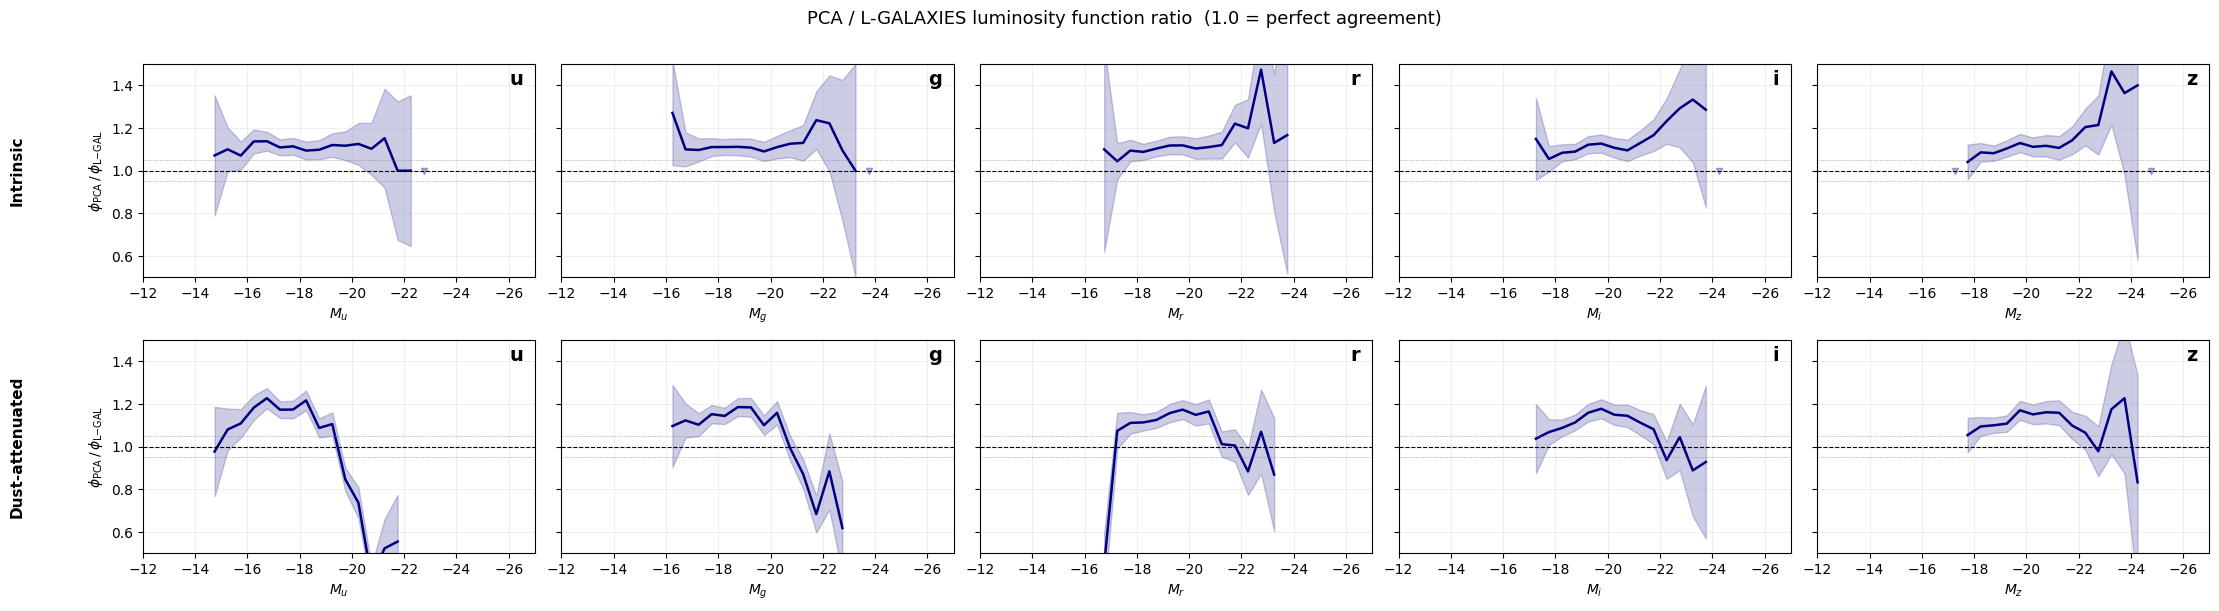

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(22, 6), sharey=True)
fig.suptitle('PCA / L-GALAXIES luminosity function ratio  (1.0 = perfect agreement)',
             fontsize=13, y=1.01)

RATIO_PAIRS = [
    (0, 'pca_int',  'lgal_int',  'Intrinsic'),
    (1, 'pca_dust', 'lgal_dust', 'Dust-attenuated'),
]

for row, key_pca, key_lg, row_label in RATIO_PAIRS:
    for col, b in enumerate(BANDS):
        ax = axes[row, col]

        c_lg,  phi_lg,  err_lg,  cnt_lg   = lf[key_lg][b]
        c_pca, phi_pca, err_pca, cnt_pca  = lf[key_pca][b]

        # Bins where both LFs have enough galaxies
        good = (cnt_lg >= N_MIN_BINS) & (cnt_pca >= N_MIN_BINS) & (phi_lg > 0)
        poor = ~good & ((cnt_lg > 0) | (cnt_pca > 0))

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(phi_lg > 0, phi_pca / phi_lg, np.nan)
            # Propagated fractional error
            ratio_err = ratio * np.sqrt(
                (err_pca / np.where(phi_pca > 0, phi_pca, np.inf))**2 +
                (err_lg  / np.where(phi_lg  > 0, phi_lg,  np.inf))**2
            )

        if good.any():
            ax.plot(c_lg[good], ratio[good], color='navy', lw=1.8)
            ax.fill_between(c_lg[good],
                            ratio[good] - ratio_err[good],
                            ratio[good] + ratio_err[good],
                            alpha=0.20, color='navy')
        if poor.any():
            ax.scatter(c_lg[poor], ratio[poor], marker='v', s=20,
                       color='navy', alpha=0.30)

        ax.axhline(1.0, color='k', lw=0.8, ls='--')
        ax.axhline(1.05, color='gray', lw=0.5, ls=':')
        ax.axhline(0.95, color='gray', lw=0.5, ls=':')
        ax.set_xlim(MAG_MAX, MAG_MIN)
        ax.set_ylim(0.5, 1.5)
        ax.set_xlabel(f'$M_{{{b}}}$', fontsize=10)
        ax.grid(alpha=0.2)
        ax.text(0.97, 0.97, b, transform=ax.transAxes,
                ha='right', va='top', fontsize=14, fontweight='bold')

        if col == 0:
            ax.set_ylabel(r'$\phi_{\rm PCA} \,/\, \phi_{\rm L{-}GAL}$', fontsize=10)
            ax.text(-0.30, 0.50, row_label, transform=ax.transAxes,
                    rotation=90, va='center', ha='right', fontsize=11,
                    fontweight='bold')

plt.tight_layout()
plt.savefig(GALSPECTRA_ROOT / 'data' / 'lf_comparison_ratio.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. r-band summary — all four LFs with SDSS reference

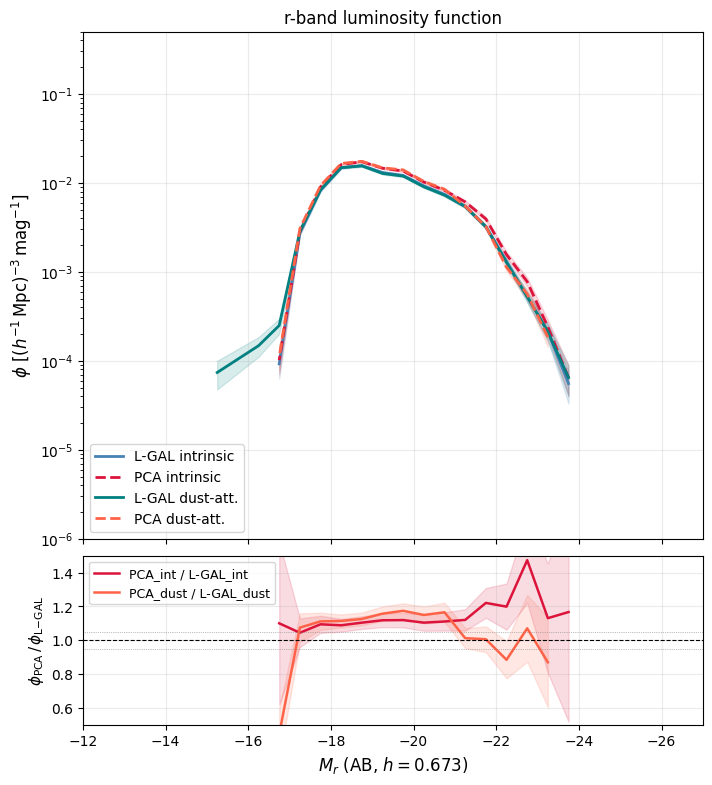

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8, 9),
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
ax_lf, ax_res = axes

# ── LF panel ──────────────────────────────────────────────────────────────
STYLES_R = {
    'lgal_int' : dict(color='steelblue', lw=2.0, ls='-',  label='L-GAL intrinsic'),
    'pca_int'  : dict(color='crimson',   lw=2.0, ls='--', label='PCA intrinsic'),
    'lgal_dust': dict(color='teal',      lw=2.0, ls='-',  label='L-GAL dust-att.'),
    'pca_dust' : dict(color='tomato',    lw=2.0, ls='--', label='PCA dust-att.'),
}

for key in ('lgal_int', 'pca_int', 'lgal_dust', 'pca_dust'):
    c, phi, err, cnt = lf[key]['r']
    good = cnt >= N_MIN_BINS
    kw = STYLES_R[key]
    if good.any():
        ax_lf.semilogy(c[good], phi[good], **kw)
        ax_lf.fill_between(c[good],
                           np.maximum(phi[good] - err[good], 1e-9),
                           phi[good] + err[good],
                           alpha=0.15, color=kw['color'])

M_ref = np.linspace(MAG_MIN, MAG_MAX, 400)
# ax_lf.semilogy(M_ref, schechter_r(M_ref), color='gray', lw=1.5, ls=':',
#                label='SDSS Schechter (Blanton+03, z~0.1)')

ax_lf.set_xlim(MAG_MAX, MAG_MIN)
ax_lf.set_ylim(1e-6, 5e-1)
ax_lf.set_ylabel(r'$\phi$ $[(h^{-1}\,{\rm Mpc})^{-3}\,{\rm mag}^{-1}]$', fontsize=12)
ax_lf.legend(fontsize=10, loc='lower left')
ax_lf.grid(alpha=0.25)
ax_lf.set_title('r-band luminosity function', fontsize=12)
ax_lf.tick_params(labelbottom=False)

# ── Ratio panel ────────────────────────────────────────────────────────────
for key_pca, key_lg, color, label in [
        ('pca_int',  'lgal_int',  'crimson', 'PCA_int / L-GAL_int'),
        ('pca_dust', 'lgal_dust', 'tomato',  'PCA_dust / L-GAL_dust'),
]:
    c_lg,  phi_lg,  err_lg,  cnt_lg   = lf[key_lg]['r']
    c_pca, phi_pca, err_pca, cnt_pca  = lf[key_pca]['r']
    good = (cnt_lg >= N_MIN_BINS) & (cnt_pca >= N_MIN_BINS) & (phi_lg > 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(phi_lg > 0, phi_pca / phi_lg, np.nan)
        rerr  = ratio * np.sqrt(
            (err_pca / np.where(phi_pca > 0, phi_pca, np.inf))**2 +
            (err_lg  / np.where(phi_lg  > 0, phi_lg,  np.inf))**2)
    if good.any():
        ax_res.plot(c_lg[good], ratio[good], color=color, lw=1.8, label=label)
        ax_res.fill_between(c_lg[good],
                            ratio[good] - rerr[good],
                            ratio[good] + rerr[good],
                            alpha=0.15, color=color)

ax_res.axhline(1.0,  color='k',    lw=0.8, ls='--')
ax_res.axhline(1.05, color='gray', lw=0.5, ls=':')
ax_res.axhline(0.95, color='gray', lw=0.5, ls=':')
ax_res.set_xlim(MAG_MAX, MAG_MIN)
ax_res.set_ylim(0.5, 1.5)
ax_res.set_xlabel(r'$M_r$ (AB, $h = 0.673$)', fontsize=12)
ax_res.set_ylabel(r'$\phi_{\rm PCA}\,/\,\phi_{\rm L{-}GAL}$', fontsize=11)
ax_res.legend(fontsize=9)
ax_res.grid(alpha=0.25)

plt.savefig(GALSPECTRA_ROOT / 'data' / 'lf_rband_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary statistics

In [10]:
def peak_magnitude(centres, phi, counts, n_min=N_MIN_BINS):
    """Return the magnitude of the peak phi (mode of the LF) and peak phi value."""
    good = counts >= n_min
    if not good.any():
        return np.nan, np.nan
    idx = np.argmax(phi[good])
    return float(centres[good][idx]), float(phi[good][idx])


def integrated_density(centres, phi, counts, M_lo=-24.0, M_hi=-16.0, n_min=N_MIN_BINS):
    """Integrate phi over [M_lo, M_hi] using the trapezoidal rule."""
    good  = (counts >= n_min) & (centres >= M_lo) & (centres <= M_hi)
    if good.sum() < 2:
        return np.nan
    return float(np.trapezoid(phi[good], centres[good]))


print(f'\n{"":-<78}')
print(f'{"Band & source":<24} {"M_peak":>7} {"φ_peak":>12} {"∫φ dM (−24 to −16)":>22}')
print(f'{"":-<78}')

LABELS = {
    'lgal_int':  'L-GAL Mag (intrinsic)',
    'pca_int':   'PCA synth_mag',
    'lgal_dust': 'L-GAL MagDust',
    'pca_dust':  'PCA synth_magdust',
}

for b in BANDS:
    for key in ('lgal_int', 'pca_int', 'lgal_dust', 'pca_dust'):
        c, phi, err, cnt = lf[key][b]
        Mp, phiP = peak_magnitude(c, phi, cnt)
        integ    = integrated_density(c, phi, cnt)
        lbl = f'{b}-{LABELS[key]}'
        print(f'{lbl:<24} {Mp:>7.2f} {phiP:>12.3e} {integ:>22.3e}')
    print(f'{"":-<78}')


------------------------------------------------------------------------------
Band & source             M_peak       φ_peak     ∫φ dM (−24 to −16)
------------------------------------------------------------------------------
u-L-GAL Mag (intrinsic)   -17.25    1.560e-02              4.179e-02
u-PCA synth_mag           -17.25    1.730e-02              4.653e-02
u-L-GAL MagDust           -17.25    1.529e-02              4.121e-02
u-PCA synth_magdust       -17.25    1.794e-02              4.614e-02
------------------------------------------------------------------------------
g-L-GAL Mag (intrinsic)   -18.25    1.566e-02              4.696e-02
g-PCA synth_mag           -18.25    1.740e-02              5.219e-02
g-L-GAL MagDust           -18.25    1.545e-02              4.657e-02
g-PCA synth_magdust       -18.25    1.767e-02              5.216e-02
------------------------------------------------------------------------------
r-L-GAL Mag (intrinsic)   -18.75    1.567e-02              4.7